-------------------------------
-------------------------------
# Laboratorio #7 - IA (CC3085)
* Dulce Ambrosio - 231143
* Daniel Chet - 231177
* Gadiel Ocaña - 231270

-------------------------------
-------------------------------

-------------------------------
## Task 2.1 (Lab6) - Diseño del juego (Connect Four)
-------------------------------

In [57]:
# Inicialización y Constantes
# Importaciones necesarias
import numpy as np
import math
import random
import time
from IPython.display import clear_output

# Constantes del juego
ROWS = 6
COLS = 7

PLAYER = 1
AI = 2
EMPTY = 0

In [58]:
# Creación del tablero y manejo de movimientos
def create_board():
    return np.zeros((ROWS, COLS), dtype=int)

# Actions (posbles acciones) - Diapositiva 6
# Una columna es valida si la posicion superior esta vacia
def get_valid_moves(board):
    valid_moves = []
    for col in range(COLS):
        if board[ROWS-1][col] == 0:
            valid_moves.append(col)
    return valid_moves

# Succ(s,a), se aplican los movimiento - Diapositiva 6
def drop_piece(board, col, piece):
    new_board = board.copy()
    for row in range(ROWS):
        if new_board[row][col] == 0:
            new_board[row][col] = piece
            break
    return new_board

In [59]:
# Detección de victoria (IsEnd)
# IsEnd(s), se verifica la victoria - Diapositiva 6
def winning_move(board, piece):
    # Horizontal
    for c in range(COLS-3):
        for r in range(ROWS):
            if board[r][c] == piece and board[r][c+1] == piece and board[r][c+2] == piece and board[r][c+3] == piece:
                return True
    # Vertical
    for c in range(COLS):
        for r in range(ROWS-3):
            if board[r][c] == piece and board[r+1][c] == piece and board[r+2][c] == piece and board[r+3][c] == piece:
                return True
    # Diagonal positiva (/)
    for c in range(COLS-3):
        for r in range(ROWS-3):
            if board[r][c] == piece and board[r+1][c+1] == piece and board[r+2][c+2] == piece and board[r+3][c+3] == piece:
                return True
    # Diagonal negativa (\)
    for c in range(COLS-3):
        for r in range(3, ROWS):
            if board[r][c] == piece and board[r-1][c+1] == piece and board[r-2][c+2] == piece and board[r-3][c+3] == piece:
                return True
    return False

# Estado terminal - Diapositiva 8
# Verificación de condición de victoria.
# Esto permite identificar estados terminales del juego.
def is_terminal(board):
    return winning_move(board, PLAYER) or winning_move(board, AI) or len(get_valid_moves(board)) == 0

-------------------------------
## Task 2.2 (Lab6) - Se implementa la Poda Alfa-Beta
-------------------------------

In [60]:
# Placeholder - Esta función será detallada en el Task 2.3
# Función evaluate(board) - Esta función recorre todo el tablero buscando ventanas de 4. - Diapositiva 37
# Implementación de Eval(s).
# Esta heurística estima qué tan favorable es el tablero
# cuando no se puede llegar a un estado terminal.
def evaluate(board, piece):
    return 0 

nodes_minimax = 0
nodes_alphabeta = 0
# Minimax sin poda - Diapositiva 41
# Versión clásica de Minimax para comparar con Alfa-Beta.
def minimax(board, depth, maximizing):
    
    global nodes_minimax
    nodes_minimax += 1
    is_term = is_terminal(board)
    if depth == 0 or is_term:
        if is_term:
            if winning_move(board, AI): return (None, 10000000)
            elif winning_move(board, PLAYER): return (None, -10000000)
            else: return (None, 0)
        else:
            return (None, evaluate(board, AI))
    valid_moves = get_valid_moves(board)
    if maximizing:
        value = -math.inf
        best_col = random.choice(valid_moves)
        for col in valid_moves:
            temp_board = drop_piece(board, col, AI)
            new_score = minimax(temp_board, depth-1, False)[1]
            if new_score > value:
                value = new_score
                best_col = col
        return best_col, value
    else:
        value = math.inf
        best_col = random.choice(valid_moves)
        for col in valid_moves:
            temp_board = drop_piece(board, col, PLAYER)
            new_score = minimax(temp_board, depth-1, True)[1]
            if new_score < value:
                value = new_score
                best_col = col
        return best_col, value

# Minimax con poda alpha-beta - Diapositiva 43
# Versión optimizada de Minimax usando poda Alpha-Beta.
# Los valores alpha y beta representan los límites inferior
# y superior de los nodos MAX y MIN respectivamente.
# Si alpha >= beta se puede podar la rama.
def alphabeta(board, depth, alpha, beta, maximizing):
    global nodes_alphabeta
    nodes_alphabeta += 1
    is_term = is_terminal(board)
    if depth == 0 or is_term:
        if is_term:
            if winning_move(board, AI): return (None, 10000000)
            elif winning_move(board, PLAYER): return (None, -10000000)
            else: return (None, 0)
        else:
            return (None, evaluate(board, AI)) # Llama al placeholder

    valid_moves = get_valid_moves(board)
    if maximizing:
        value = -math.inf
        best_col = random.choice(valid_moves)
        for col in valid_moves:
            temp_board = drop_piece(board, col, AI)
            new_score = alphabeta(temp_board, depth-1, alpha, beta, False)[1]
            if new_score > value:
                value = new_score
                best_col = col
            alpha = max(alpha, value)
            if alpha >= beta: break
        return best_col, value
    else:
        value = math.inf
        best_col = random.choice(valid_moves)
        for col in valid_moves:
            temp_board = drop_piece(board, col, PLAYER)
            new_score = alphabeta(temp_board, depth-1, alpha, beta, True)[1]
            if new_score < value:
                value = new_score
                best_col = col
            beta = min(beta, value)
            if alpha >= beta: break
        return best_col, value

In [61]:
# Impresion de nodos visitados
test_board = create_board()
test_board = drop_piece(test_board, 3, PLAYER)
test_board = drop_piece(test_board, 2, AI)

nodes_minimax = 0
minimax(test_board, 4, True)

nodes_alphabeta = 0
alphabeta(test_board, 4, -math.inf, math.inf, True)

print(f"Nodos visitados por Minimax puro: {nodes_minimax}")
print(f"Nodos visitados por Alfa-Beta: {nodes_alphabeta}")
print(f"Reducción de nodos: {((nodes_minimax - nodes_alphabeta) / nodes_minimax) * 100:.2f}%")

Nodos visitados por Minimax puro: 2801
Nodos visitados por Alfa-Beta: 173
Reducción de nodos: 93.82%


-------------------------------
## Task 2.3 (Lab6) - Función evaluate(board)
-------------------------------

In [62]:
# Evaluar una ventana de 4 posiciones - Diapositiva 37
# Evaluación heurística de una ventana de 4 posiciones.
# Forma parte de la función Eval(s) usada cuando la
# búsqueda se corta en profundidad limitada.

def evaluate_window(window, piece):
    score = 0
    opp = PLAYER if piece == AI else AI
    if window.count(piece) == 4: score += 100
    elif window.count(piece) == 3 and window.count(EMPTY) == 1: score += 5
    elif window.count(piece) == 2 and window.count(EMPTY) == 2: score += 2
    if window.count(opp) == 3 and window.count(EMPTY) == 1: score -= 4
    return score

# Función evaluate(board) - Esta función recorre todo el tablero buscando ventanas de 4. - Diapositiva 37
# Implementación de Eval(s).
# Esta heurística estima qué tan favorable es el tablero
# cuando no se puede llegar a un estado terminal.
def evaluate(board, piece):
    score = 0
    # Prioridad centro
    center_array = [int(i) for i in list(board[:, COLS//2])]
    score += center_array.count(piece) * 3

    # Puntaje Horizontal, Vertical y Diagonales
    for r in range(ROWS):
        row_array = [int(i) for i in list(board[r,:])]
        for c in range(COLS-3):
            score += evaluate_window(row_array[c:c+4], piece)
    for c in range(COLS):
        col_array = [int(i) for i in list(board[:,c])]
        for r in range(ROWS-3):
            score += evaluate_window(col_array[r:r+4], piece)
    for r in range(ROWS-3):
        for c in range(COLS-3):
            window = [board[r+i][c+i] for i in range(4)]
            score += evaluate_window(window, piece)
    for r in range(3, ROWS):
        for c in range(COLS-3):
            window = [board[r-i][c+i] for i in range(4)]
            score += evaluate_window(window, piece)
    return score

In [63]:
# Juego contra un agente
def random_player_move(board):
    """
    Selecciona un movimiento legal de forma aleatoria
    """
    valid_moves = get_valid_moves(board)
    if len(valid_moves) > 0:
        return random.choice(valid_moves)
    return None

In [64]:
from IPython.display import clear_output
import numpy as np

def print_board_visual(board):
    clear_output(wait=True)
    board_view = np.flip(board, 0)

    print("\n\t=== CONECTA 4 (Lab 6) ===")
    print("\tAgente/Humano: 🅧  |  IA: ⊗\n")

    for row in board_view:
        print("\t|" + "|".join([" 🅧 " if c==1 else " ⊗ " if c==2 else " ● " for c in row]) + "|")

    print("\t-----------------------------")
    print("\t  0   1   2   3   4   5   6\n")


In [65]:
import random
import time
import math

def play_game(vs_random=True):

    board = create_board()
    turn = random.randint(PLAYER, AI)
    game_over = False

    print_board_visual(board)

    while not game_over:

        if turn == PLAYER:

            if vs_random:
                print("Agente Aleatorio 🅧 moviendo...")
                time.sleep(0.5)
                col = random_player_move(board)

            else:
                col = -1
                while col not in get_valid_moves(board):
                    try:
                        col = int(input("Tu turno 🅧 - Elige columna (0-6): "))
                    except:
                        print("Ingresa un número válido.")

            board = drop_piece(board, col, PLAYER)

            print_board_visual(board)

            if winning_move(board, PLAYER):
                print("🅧 ¡EL JUGADOR GANÓ!")
                game_over = True

            turn = AI

        else:

            print("IA ⊗ pensando (Alfa-Beta)...")
            time.sleep(0.5)

            col, _ = alphabeta(board, 5, -math.inf, math.inf, True)

            if col is not None:
                board = drop_piece(board, col, AI)

            print_board_visual(board)

            if winning_move(board, AI):
                print("⊗ ¡LA IA GANÓ!")
                game_over = True

            turn = PLAYER

        if not game_over and len(get_valid_moves(board)) == 0:
            print("¡Empate!")
            game_over = True


In [66]:
print("====================================")
print("   PARTIDA 1: IA vs Agente Aleatorio")
print("====================================")

play_game(vs_random=True)



	=== CONECTA 4 (Lab 6) ===
	Agente/Humano: 🅧  |  IA: ⊗

	| ● | ● | ● | ● | ● | ● | ● |
	| ● | ● | ● | ● | ● | ● | ● |
	| ● | ● | ● | ● | ● | ● | ● |
	| ● | ● | ● | 🅧 | ● | ● | ● |
	| ● | ⊗ | ⊗ | ⊗ | ⊗ | ● | 🅧 |
	| ● | 🅧 | 🅧 | ⊗ | ⊗ | ● | 🅧 |
	-----------------------------
	  0   1   2   3   4   5   6

⊗ ¡LA IA GANÓ!


In [67]:
'''
print("====================================")
print("   PARTIDA 2: IA vs Humano")
print("====================================")

play_game(vs_random=False)
'''

'\nprint("====================================")\nprint("   PARTIDA 2: IA vs Humano")\nprint("====================================")\n\nplay_game(vs_random=False)\n'

-------------------------------
-------------------------------
# Laboratorio #7 - IA (CC3085) 

-------------------------------
-------------------------------

-------------------------------
## Task 2.1 — Agente TD Learning (Q-Learning)
-------------------------------

In [68]:
# ================================
# Q-Learning - Inicialización
# ================================

Q = {}  # Diccionario para almacenar valores Q

alpha = 0.1   # Learning rate
gamma = 0.9   # Factor de descuento

epsilon = 1.0        # Exploración inicial
epsilon_decay = 0.995
epsilon_min = 0.01

In [69]:
# ================================
# Representación del estado
# ================================

def get_state(board):
    return tuple(board.flatten())

In [70]:
# ================================
# Funciones Q
# ================================

def get_Q(state, action):
    return Q.get((state, action), 0.0)

def update_Q(state, action, reward, next_state, valid_actions):
    max_future_Q = 0
    
    if valid_actions:
        max_future_Q = max([get_Q(next_state, a) for a in valid_actions])
    
    current_Q = get_Q(state, action)
    
    # Fórmula Q-learning
    new_Q = current_Q + alpha * (reward + gamma * max_future_Q - current_Q)
    
    Q[(state, action)] = new_Q

In [71]:
# ================================
# Función de recompensa 
# ================================

def get_reward(board, action, is_win=False, is_lose=False, is_draw=False):
    # Recompensas terminales
    if is_win:
        return 100
    if is_lose:
        return -100
    if is_draw:
        return 10
    
    # Recompensas intermedias: Priorizar el centro 
    reward = -0.1 # Pequeño castigo por cada paso (para buscar ganar rápido)
    if action == COLS // 2: # Si la acción es la columna central (3)
        reward += 2.0 
        
    return reward

In [72]:
# ================================
# Selección de acción (ε-greedy)
# ================================

def choose_action(state, valid_actions):
    if random.random() < epsilon:
        return random.choice(valid_actions)
    else:
        Q_values = [get_Q(state, a) for a in valid_actions]
        return valid_actions[np.argmax(Q_values)]

In [73]:
# ================================
# Entrenamiento del agente (Corregido)
# ================================

def train(episodes):
    global epsilon
    
    for ep in range(episodes):
        board = create_board()
        game_over = False
        
        while not game_over:
            # --- 1. TURNO DEL AGENTE (TD Learner) ---
            state = get_state(board)
            valid_actions = get_valid_moves(board)
            if not valid_actions: 
                break
            
            action = choose_action(state, valid_actions)
            board = drop_piece(board, action, 1) # Agente es pieza 1
            
            # Verificar si el agente gana o empata con este movimiento
            if winning_move(board, 1):
                reward = get_reward(board, action, is_win=True)
                update_Q(state, action, reward, get_state(board), [])
                break
            elif len(get_valid_moves(board)) == 0:
                reward = get_reward(board, action, is_draw=True)
                update_Q(state, action, reward, get_state(board), [])
                break
                
            # --- 2. TURNO DEL OPONENTE (Aleatorio) ---
            opp_valid_actions = get_valid_moves(board)
            opp_action = random.choice(opp_valid_actions)
            board = drop_piece(board, opp_action, 2) # Oponente es pieza 2
            
            # Verificar si el oponente gana con su movimiento
            if winning_move(board, 2):
                reward = get_reward(board, action, is_lose=True)
                update_Q(state, action, reward, get_state(board), [])
                break
                
            # --- 3. ACTUALIZACIÓN Q-LEARNING ---
            # Si el juego continúa, el próximo estado es el tablero actual (turno del agente de nuevo)
            reward = get_reward(board, action)
            next_state = get_state(board)
            next_valid_actions = get_valid_moves(board)
            
            update_Q(state, action, reward, next_state, next_valid_actions)
        
        # Reducir epsilon para disminuir la exploración con el tiempo
        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        
        if ep % 10000 == 0:
            print(f"Episodio {ep} completado")

In [74]:
# Entrenar el agente
train(100000)

Episodio 0 completado
Episodio 10000 completado
Episodio 20000 completado
Episodio 30000 completado
Episodio 40000 completado
Episodio 50000 completado
Episodio 60000 completado
Episodio 70000 completado
Episodio 80000 completado
Episodio 90000 completado


In [75]:
# ================================
# Agente TD (usar lo aprendido)
# ================================

def choose_best_action(state, valid_actions):
    Q_values = [get_Q(state, a) for a in valid_actions]
    return valid_actions[np.argmax(Q_values)]

In [76]:
board = create_board()
state = get_state(board)
valid = get_valid_moves(board)

print("Acción recomendada:", choose_best_action(state, valid))

Acción recomendada: 3


-------------------------------
## Task 2.2 — Competencia
-------------------------------

In [77]:
# ================================
# Funciones de agente para competencia
# ================================

def td_agent_move(board, piece=1):
    """El agente TD elige su mejor acción aprendida (sin exploración)"""
    state = get_state(board)
    valid_actions = get_valid_moves(board)
    if not valid_actions:
        return None
    return choose_best_action(state, valid_actions)

def minimax_agent_move(board, piece, depth=4):
    """Agente Minimax sin poda alpha-beta"""
    # Minimax siempre maximiza para 'piece'
    col, _ = minimax(board, depth, maximizing=(piece == AI))
    return col

def alphabeta_agent_move(board, piece, depth=4):
    """Agente Minimax con poda alpha-beta"""
    col, _ = alphabeta(board, depth, -math.inf, math.inf, maximizing=(piece == AI))
    return col

In [78]:
# ================================
# Función genérica de partida
# ================================

def play_match(agent1_fn, agent2_fn, agent1_piece=1, agent2_piece=2):
    """
    Juega una partida entre dos agentes.
    Retorna: 1 si gana agent1, 2 si gana agent2, 0 si empate
    """
    board = create_board()
    turn = random.choice([1, 2])  # quién empieza al azar
    
    while True:
        valid = get_valid_moves(board)
        if not valid:
            return 0  # empate
        
        if turn == 1:
            col = agent1_fn(board)
            piece = agent1_piece
        else:
            col = agent2_fn(board)
            piece = agent2_piece
        
        if col is None or col not in valid:
            col = random.choice(valid)
        
        board = drop_piece(board, col, piece)
        
        if winning_move(board, piece):
            return turn
        
        if len(get_valid_moves(board)) == 0:
            return 0
        
        turn = 2 if turn == 1 else 1

In [79]:
# ================================
# Las 3 condiciones
# ================================
import matplotlib.pyplot as plt

def run_condition(label, agent1_fn, agent2_fn, n=50):
    """Corre n partidas y retorna conteo de resultados"""
    wins_a1 = 0  # victorias agente 1
    wins_a2 = 0  # victorias agente 2
    draws = 0
    
    for _ in range(n):
        result = play_match(agent1_fn, agent2_fn)
        if result == 1:
            wins_a1 += 1
        elif result == 2:
            wins_a2 += 1
        else:
            draws += 1
    
    print(f"\n{label}")
    print(f"  Victorias Agente 1: {wins_a1}")
    print(f"  Victorias Agente 2: {wins_a2}")
    print(f"  Empates: {draws}")
    return wins_a1, wins_a2, draws

# Para condición A y B: TD es agente1 (pieza 1), oponente es agente2 (pieza 2)
# El minimax/alphabeta internamente siempre maximiza para AI=2 — así que el oponente debe ser pieza 2
td_fn  = lambda board: td_agent_move(board)
mm_fn  = lambda board: minimax(board, 3, True)[0]   # maximiza para AI(2)
ab_fn  = lambda board: alphabeta(board, 3, -math.inf, math.inf, True)[0]

# Para condición C: ambos son "AI" en tableros separados
# Minimax juega como agente1 (pieza 1) pero tomando decisiones como maximizador
# La solución correcta: el agente1 invierte el tablero para verse como AI
def mm_as_p1(board):
    # Intercambia piezas temporalmente para que minimax maximice como pieza 1
    swapped = np.where(board == 1, 2, np.where(board == 2, 1, 0))
    col, _ = minimax(swapped, 3, True)
    return col

def ab_as_p2(board):
    # alphabeta ya maximiza para pieza 2 (AI), directo
    col, _ = alphabeta(board, 3, -math.inf, math.inf, True)
    return col

# Condición A: TD vs Minimax
res_A = run_condition("Condición A: TD vs Minimax", td_fn, mm_fn, n=50)

# Condición B: TD vs Minimax+AlphaBeta  
res_B = run_condition("Condición B: TD vs Minimax+AlphaBeta", td_fn, ab_fn, n=50)

# Condición C: Minimax vs Minimax+AlphaBeta
res_C = run_condition("Condición C: Minimax vs Minimax+AlphaBeta", mm_as_p1, ab_as_p2, n=50)


Condición A: TD vs Minimax
  Victorias Agente 1: 0
  Victorias Agente 2: 50
  Empates: 0

Condición B: TD vs Minimax+AlphaBeta
  Victorias Agente 1: 0
  Victorias Agente 2: 50
  Empates: 0

Condición C: Minimax vs Minimax+AlphaBeta
  Victorias Agente 1: 32
  Victorias Agente 2: 18
  Empates: 0


In [80]:
# ================================
# Task 2.3 — Partidas Representativas (para video)
# Muestra una partida visual entre dos agentes con delay
# ================================

def print_board_video(board, label_p1, label_p2, move_info=""):
    """Imprime el tablero con etiquetas personalizadas por agente"""
    clear_output(wait=True)
    board_view = np.flip(board, 0)

    print(f"\n\t=== CONECTA 4 — Lab 7 ===")
    print(f"\t  {label_p1}: 🔵   |   {label_p2}: 🔴")
    if move_info:
        print(f"\t  {move_info}")
    print()

    for row in board_view:
        print("\t|" + "|".join(
            [f" 🔵 " if c == 1 else " 🔴 " if c == 2 else " ·  " for c in row]
        ) + "|")

    print("\t-----------------------------")
    print("\t   0    1    2    3    4    5    6\n")


def play_visual_match(agent1_fn, agent2_fn, label_p1, label_p2, delay=0.6):
    """
    Juega una partida visual entre dos agentes mostrando el tablero en cada turno.
    agent1 juega pieza 1 (🔵), agent2 juega pieza 2 (🔴)
    """
    board = create_board()
    # Turno aleatorio para que no siempre empiece el mismo
    turn = random.choice([1, 2])
    game_over = False

    print_board_video(board, label_p1, label_p2, "Iniciando partida...")
    time.sleep(delay)

    while not game_over:
        valid = get_valid_moves(board)
        if not valid:
            print_board_video(board, label_p1, label_p2)
            print("\t¡EMPATE!")
            break

        if turn == 1:
            col = agent1_fn(board)
            if col is None or col not in valid:
                col = random.choice(valid)
            board = drop_piece(board, col, 1)
            move_info = f"Turno de {label_p1} → columna {col}"
            print_board_video(board, label_p1, label_p2, move_info)
            time.sleep(delay)

            if winning_move(board, 1):
                print(f"\t¡{label_p1} (🔵) GANÓ!")
                game_over = True
                break
            turn = 2

        else:
            col = agent2_fn(board)
            if col is None or col not in valid:
                col = random.choice(valid)
            board = drop_piece(board, col, 2)
            move_info = f"Turno de {label_p2} → columna {col}"
            print_board_video(board, label_p1, label_p2, move_info)
            time.sleep(delay)

            if winning_move(board, 2):
                print(f"\t¡{label_p2} (🔴) GANÓ!")
                game_over = True
                break
            turn = 1

        if len(get_valid_moves(board)) == 0 and not game_over:
            print("\t¡EMPATE!")
            break

In [85]:
# ================================
# PARTIDA REPRESENTATIVA — Condición A
# TD Learning vs Minimax sin poda
# ================================

td_fn_vis = lambda board: td_agent_move(board)
mm_fn_vis = lambda board: minimax(board, 3, True)[0]

print("=" * 45)
print("  CONDICIÓN A: TD Learning vs Minimax")
print("=" * 45)

play_visual_match(td_fn_vis, mm_fn_vis,
                  label_p1="TD Learning",
                  label_p2="Minimax",
                  delay=0.8)


	=== CONECTA 4 — Lab 7 ===
	  TD Learning: 🔵   |   Minimax: 🔴
	  Turno de Minimax → columna 1

	| 🔵 | ·  | ·  | ·  | ·  | ·  | ·  |
	| 🔵 | ·  | ·  | ·  | ·  | ·  | ·  |
	| 🔴 | ·  | ·  | ·  | ·  | ·  | ·  |
	| 🔵 | ·  | ·  | ·  | ·  | ·  | ·  |
	| 🔵 | ·  | ·  | 🔴 | ·  | ·  | ·  |
	| 🔵 | 🔴 | 🔴 | 🔴 | 🔴 | ·  | ·  |
	-----------------------------
	   0    1    2    3    4    5    6

	¡Minimax (🔴) GANÓ!


In [86]:
# ================================
# PARTIDA REPRESENTATIVA — Condición B
# TD Learning vs Minimax + Alpha-Beta
# ================================

ab_fn_vis = lambda board: alphabeta(board, 3, -math.inf, math.inf, True)[0]

print("=" * 45)
print("  CONDICIÓN B: TD Learning vs Alpha-Beta")
print("=" * 45)

play_visual_match(td_fn_vis, ab_fn_vis,
                  label_p1="TD Learning",
                  label_p2="Alpha-Beta",
                  delay=0.8)


	=== CONECTA 4 — Lab 7 ===
	  TD Learning: 🔵   |   Alpha-Beta: 🔴
	  Turno de Alpha-Beta → columna 5

	| ·  | ·  | ·  | 🔴 | ·  | ·  | ·  |
	| ·  | ·  | ·  | 🔵 | ·  | 🔴 | ·  |
	| ·  | ·  | ·  | 🔵 | ·  | 🔴 | ·  |
	| 🔵 | ·  | ·  | 🔵 | ·  | 🔴 | ·  |
	| 🔵 | ·  | 🔴 | 🔴 | ·  | 🔴 | ·  |
	| 🔵 | ·  | 🔴 | 🔵 | ·  | 🔵 | ·  |
	-----------------------------
	   0    1    2    3    4    5    6

	¡Alpha-Beta (🔴) GANÓ!


In [87]:
# ================================
# PARTIDA REPRESENTATIVA — Condición C
# Minimax vs Minimax + Alpha-Beta (control)
# ================================

def mm_as_p1_vis(board):
    # Intercambia piezas para que minimax maximice como pieza 1
    swapped = np.where(board == 1, 2, np.where(board == 2, 1, 0))
    col, _ = minimax(swapped, 3, True)
    return col

print("=" * 45)
print("  CONDICIÓN C: Minimax vs Alpha-Beta (control)")
print("=" * 45)

play_visual_match(mm_as_p1_vis, ab_fn_vis,
                  label_p1="Minimax",
                  label_p2="Alpha-Beta",
                  delay=0.8)


	=== CONECTA 4 — Lab 7 ===
	  Minimax: 🔵   |   Alpha-Beta: 🔴
	  Turno de Minimax → columna 4

	| 🔵 | 🔴 | 🔵 | 🔴 | ·  | ·  | ·  |
	| 🔴 | 🔴 | 🔴 | 🔵 | ·  | ·  | ·  |
	| 🔵 | 🔵 | 🔵 | 🔴 | ·  | ·  | ·  |
	| 🔴 | 🔴 | 🔴 | 🔵 | ·  | ·  | ·  |
	| 🔵 | 🔵 | 🔵 | 🔴 | 🔵 | ·  | ·  |
	| 🔴 | 🔴 | 🔴 | 🔵 | 🔵 | 🔵 | ·  |
	-----------------------------
	   0    1    2    3    4    5    6

	¡Minimax (🔵) GANÓ!


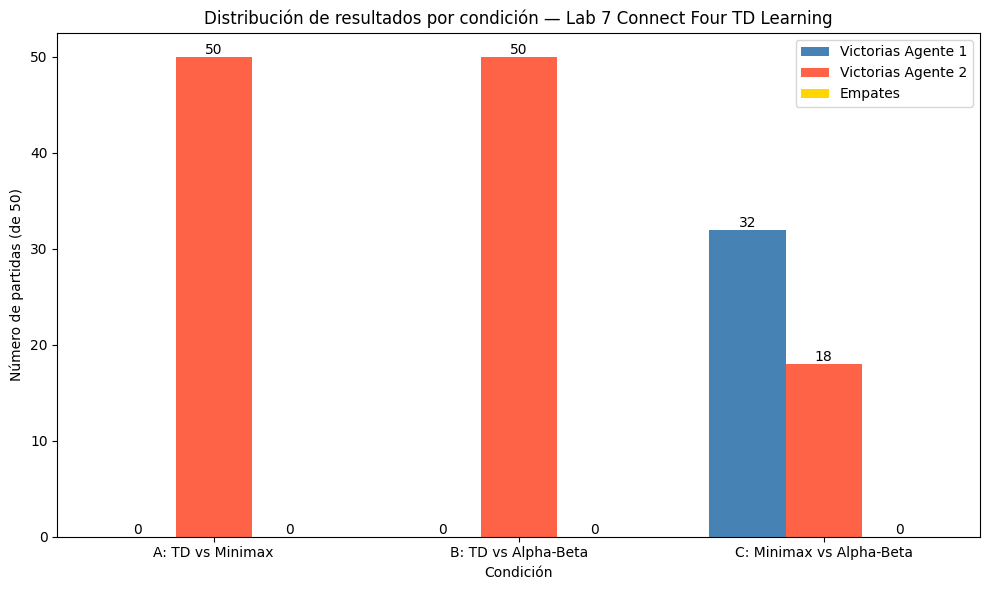

Gráfica guardada como resultados_lab7.pdf


In [88]:
# ================================
# Gráfica de resultados 
# ================================

conditions = ['A: TD vs Minimax', 'B: TD vs Alpha-Beta', 'C: Minimax vs Alpha-Beta']
results = [res_A, res_B, res_C]

vic_a1 = [r[0] for r in results]
vic_a2 = [r[1] for r in results]
empates = [r[2] for r in results]

x = np.arange(len(conditions))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width, vic_a1, width, label='Victorias Agente 1', color='steelblue')
bars2 = ax.bar(x,         vic_a2, width, label='Victorias Agente 2', color='tomato')
bars3 = ax.bar(x + width, empates, width, label='Empates',            color='gold')

ax.set_xlabel('Condición')
ax.set_ylabel('Número de partidas (de 50)')
ax.set_title('Distribución de resultados por condición — Lab 7 Connect Four TD Learning')
ax.set_xticks(x)
ax.set_xticklabels(conditions)
ax.legend()
ax.bar_label(bars1)
ax.bar_label(bars2)
ax.bar_label(bars3)

plt.tight_layout()
plt.savefig('resultados_lab7.pdf')
plt.show()
print("Gráfica guardada como resultados_lab7.pdf")